# Visualizations and Export

This notebook renders one small pSprout space in several styles and exports two different formats:

- a CSV containing SMILES, node type, descriptors, and metadata;
- a GML graph with selected node and edge attributes for tools such as Gephi.

All generated files are written to `Documentation/exports/`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from psprout import ExhaustiveExpansionAgent, GraphStyle, Space
from psprout.modifications import ModificationLibrary

output_dir = Path("Documentation/exports")
output_dir.mkdir(parents=True, exist_ok=True)

library = ModificationLibrary.load("simple")
space = Space(support_molecules=["c1ccccc1", "CO"])
agent = ExhaustiveExpansionAgent(
    space,
    [library.AddHydroxyl, library.AddFormyl, library.AddAmino],
)
list(agent.run(max_iterations=1))
graph = space.get_graph()

print(f"Prepared {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges")

Prepared 11 nodes and 9 edges


## Render the same graph in different styles

`space.view()` returns a `SpaceView`. A `GraphStyle` controls support/generated node colors, node sizes, background, and font color. The `spring` layout works without optional Graphviz support; `tree` is available when `pygraphviz` is installed.

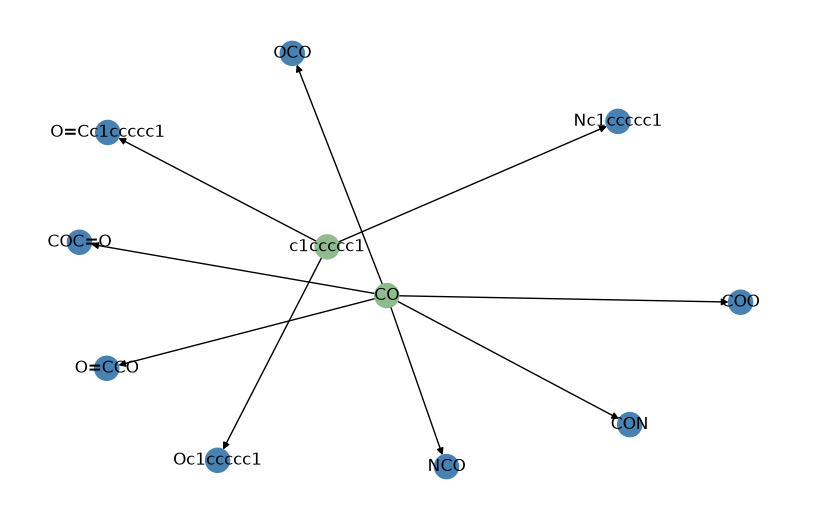

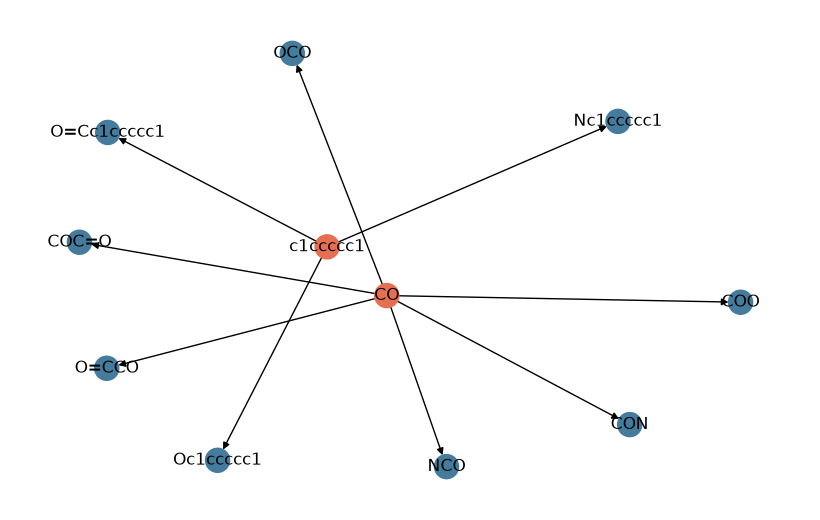

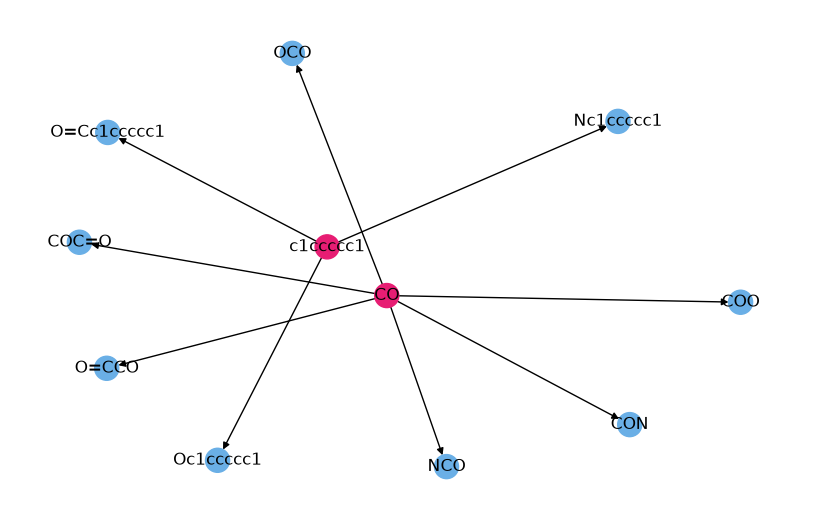

Wrote interactive graph: Documentation/exports/space-interactive.html


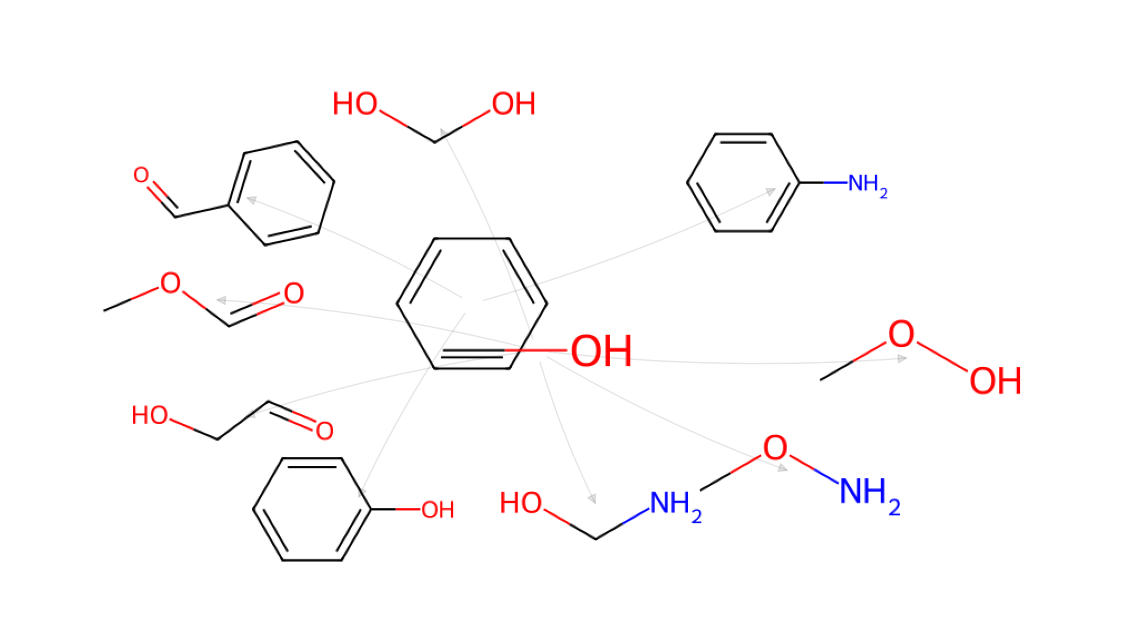

In [2]:
styles = {
    "default": GraphStyle.default(),
    "mellow": GraphStyle.mellow(),
    "contrast": GraphStyle.contrast(),
}

for name, style in styles.items():
    view = space.view(style=style, layout="spring")
    view.to_matplotlib(figsize=(8, 5), show=False)
    plt.savefig(output_dir / f"space-{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

interactive_html = space.view(style=GraphStyle.dark(), layout="spring").to_html(
    str(output_dir / "space-interactive.html")
)
print(f"Wrote interactive graph: {interactive_html}")

# Draw molecular structures directly at graph nodes in the notebook.
space.view(style=GraphStyle.mellow(), layout="spring").to_structures(figsize=(12, 7))

## Inspect generated molecules

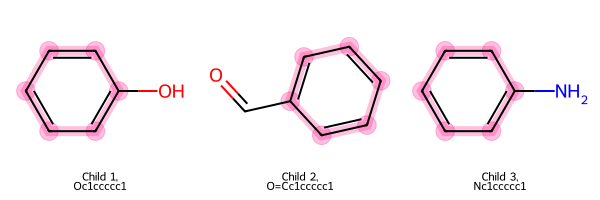

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

g = space.get_graph()
parent = space.support_molecules[0]
children = list(g.successors(parent.id))

opts = Draw.MolDrawOptions()
opts.highlightColour = (1.0, 0.0, 0.5, 
                        0.25)  # RGB, alpha

highlight_atom_lists = []
for c in children:
    mol = Chem.MolFromSmiles(c)
    matches_for_mol = mol.GetSubstructMatches(Chem.MolFromSmarts(parent.id))
    if matches_for_mol:
        # flatten the match tuples for the first match only
        highlight_atom_lists.append(list(matches_for_mol[0]))
    else:
        highlight_atom_lists.append([])
        
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(mol) for mol in children],
    highlightAtomLists=highlight_atom_lists,
    molsPerRow=3,
    subImgSize=[200, 200],
    legends=[f"Child {index + 1},\n{children[index]}" for index in range(len(children))],
    drawOptions=opts,
)

## Export nodes to CSV and network topology to GML

The live pSprout graph stores Python objects in node attributes, which are useful in Python but are not directly portable to GML. The export below builds a GML-safe graph with selected scalar attributes and JSON-encoded descriptor and metadata records.

In [4]:
node_rows = []
for smiles, attributes in graph.nodes(data=True):
    molecule = attributes["molecule"]
    node_rows.append(
        {
            "smiles": smiles,
            "name": molecule.metadata.get("name"),
            "node_type": molecule.metadata.get("type", "generated"),
            **molecule.descriptors,
            "metadata": json.dumps(molecule.metadata, sort_keys=True),
        }
    )

nodes = pd.DataFrame(node_rows).sort_values("smiles")
csv_path = output_dir / "space-nodes.csv"
nodes.to_csv(csv_path, index=False, encoding="utf-8")

export_graph = nx.DiGraph()
for smiles, attributes in graph.nodes(data=True):
    molecule = attributes["molecule"]
    export_graph.add_node(
        smiles,
        smiles=smiles,
        name=molecule.metadata.get("name") or "",
        node_type=molecule.metadata.get("type", "generated"),
        exact_mol_wt=float(molecule.descriptors["exact_mol_wt"]),
        logp=float(molecule.descriptors["logp"]),
        descriptors=json.dumps(molecule.descriptors, sort_keys=True),
        metadata=json.dumps(molecule.metadata, sort_keys=True),
    )
for source, target, attributes in graph.edges(data=True):
    export_graph.add_edge(
        source,
        target,
        modification=str(attributes.get("modification", "")),
    )

gml_path = output_dir / "space.gml"
nx.write_gml(export_graph, gml_path)

print(f"Wrote {csv_path} and {gml_path}")
nodes.head()

Wrote Documentation/exports/space-nodes.csv and Documentation/exports/space.gml


,smiles,name,node_type,exact_mol_wt,num_atoms,num_bonds,num_rings,num_h_donors,num_h_acceptors,logp,metadata
1,CO,None,support,32.026215,2,1,0,1,1,-0.3915,"{""type"": ""support""}"
8,COC=O,None,generated,60.021129,4,3,0,0,2,-0.2108,{}
10,CON,None,generated,47.037114,3,2,0,1,2,-0.4935,{}
6,COO,None,generated,48.021129,3,2,0,1,2,0.1058,{}
9,NCO,None,generated,47.037114,3,2,0,2,2,-1.1051,{}


## Validate the exports

Reload both artifacts before handing them to another tool or workflow. The checks below confirm that the exported node and edge counts match the in-memory pSprout space and that the required CSV columns are present.

In [5]:
reloaded_nodes = pd.read_csv(csv_path)
reloaded_graph = nx.read_gml(gml_path)

required_columns = {"smiles", "node_type", "exact_mol_wt", "logp", "metadata"}
assert required_columns <= set(reloaded_nodes.columns)
assert len(reloaded_nodes) == graph.number_of_nodes()
assert reloaded_graph.number_of_nodes() == graph.number_of_nodes()
assert reloaded_graph.number_of_edges() == graph.number_of_edges()

print("Export integrity check passed")
print(f"CSV rows: {len(reloaded_nodes)}")
print(
    f"GML nodes/edges: "
    f"{reloaded_graph.number_of_nodes()}/{reloaded_graph.number_of_edges()}"
)

Export integrity check passed
CSV rows: 11
GML nodes/edges: 11/9
